# Chapter 12: Classification of Surfaces

Source orientation: printed pages 468-498; sections 74-78. This notebook is original course material. It uses the source span only to choose the mathematical coverage: polygonal regions, edge labelling schemes, quotient surfaces, elementary cutting and pasting operations, orientability, standard forms, triangulation, and the classification theorem.

## Chapter Question

How can a compact connected surface be recognized from a finite edge-word?

The chapter's computational object is a polygon schema. A schema records the boundary edges of a polygon, the labels that are pasted together, and the orientations of those paste maps. From that finite word we can inspect three kinds of evidence: vertex identifications, orientability, and Euler characteristic. The classification theorem then says that, after elementary scheme operations, every paired polygon surface is a sphere, a connected sum of tori, or a connected sum of projective planes.

## Visualization Storyboard And Library Routing

- `surface-polygon-schema.png`: side-by-side edge-word diagrams for the torus, projective plane, Klein bottle, and a genus-two torus. Matplotlib is the right route because the data is an oriented boundary word.
- `orientability-test-strips.png`: orientation-pair diagnostics showing the difference between opposite-sign pairings and same-sign pairings. The invariant is the sign multiset for each label.
- `euler-characteristic-ledger.png`: vertex/edge/face accounting for standard schemas. The check computes identifications rather than trusting labels.
- `classification-reduction-flow.png`: proof-state graph for elementary operations: cut, paste, flip, permute, cancel, extract projective pairs, extract torus commutators, and absorb torus handles into projective pairs.
- `surface-standard-models.html`: rotatable sphere, torus, and crosscap-style projective-plane proxy so the standard-form names are visible as shapes, with a note that the quotient checks carry the exact topology.
- `triangulation-to-polygon-quotient.png`: a finite triangulation-to-one-polygon scaffold that shows why section 78 turns triangulated compact surfaces into edge-pairing data.


In [1]:
from pathlib import Path
import csv
import json
import math
import sys

HERE = Path.cwd()
BOOK_ROOT = HERE if (HERE / "AGENTS.md").exists() else HERE.parent
while not (BOOK_ROOT / "AGENTS.md").exists() and BOOK_ROOT != BOOK_ROOT.parent:
    BOOK_ROOT = BOOK_ROOT.parent
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import plotly.graph_objects as go
from matplotlib.patches import FancyArrowPatch, Polygon, Rectangle

from utils.artifacts import ARTIFACT_ROOT, assert_artifacts, display_artifact, image_stats, save_json, save_table
from utils.validation import assert_png_nonblank

CHAPTER_ARTIFACT = ARTIFACT_ROOT / "chapter-12"
FIGURES = CHAPTER_ARTIFACT / "figures"
HTML = CHAPTER_ARTIFACT / "html"
CHECKS = CHAPTER_ARTIFACT / "checks"
TABLES = CHAPTER_ARTIFACT / "tables"
for folder in [FIGURES, HTML, CHECKS, TABLES]:
    folder.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 170,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
})

artifact_paths = {}
checks = {}

def rel(path):
    return Path(path).resolve().relative_to(BOOK_ROOT).as_posix()

def save_fig(fig, filename):
    out = FIGURES / filename
    fig.savefig(out, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    return out

class DSU:
    def __init__(self, n):
        self.parent = list(range(n))
    def find(self, x):
        while self.parent[x] != x:
            self.parent[x] = self.parent[self.parent[x]]
            x = self.parent[x]
        return x
    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra != rb:
            self.parent[rb] = ra
    def classes(self):
        groups = {}
        for i in range(len(self.parent)):
            groups.setdefault(self.find(i), []).append(i)
        return list(groups.values())

def parse_word(word):
    tokens = []
    for raw in word.split():
        if raw.endswith("-"):
            tokens.append((raw[:-1], -1))
        else:
            tokens.append((raw, 1))
    return tokens

def edge_endpoint(edge_index, sign, n):
    start, end = edge_index, (edge_index + 1) % n
    return (start, end) if sign == 1 else (end, start)

def schema_invariants(word, faces=1):
    tokens = parse_word(word)
    n = len(tokens)
    dsu = DSU(n)
    by_label = {}
    for i, (label, sign) in enumerate(tokens):
        by_label.setdefault(label, []).append((i, sign))
    proper = all(len(v) == 2 for v in by_label.values())
    for pairs in by_label.values():
        if len(pairs) != 2:
            continue
        (i, si), (j, sj) = pairs
        a0, a1 = edge_endpoint(i, si, n)
        b0, b1 = edge_endpoint(j, sj, n)
        dsu.union(a0, b0)
        dsu.union(a1, b1)
    vertex_classes = dsu.classes()
    label_signs = {label: [sign for _, sign in pairs] for label, pairs in by_label.items()}
    orientable = all(sorted(signs) == [-1, 1] for signs in label_signs.values() if len(signs) == 2)
    V = len(vertex_classes)
    E = len(by_label)
    F = faces
    return {
        "word": word,
        "edge_count": n,
        "label_count": E,
        "proper": proper,
        "orientable_by_signs": orientable,
        "vertex_classes": vertex_classes,
        "V": V,
        "E": E,
        "F": F,
        "chi": V - E + F,
        "label_signs": label_signs,
    }

standard_words = {
    "sphere_cancelled_bigons": "a a- b b-",
    "torus": "a b a- b-",
    "projective_plane_two_gon": "a a",
    "klein_bottle": "a b a- b",
    "double_torus": "a b a- b- c d c- d-",
    "three_projective_planes": "a a b b c c",
}
ledger = {name: schema_invariants(word) for name, word in standard_words.items()}
checks["torus_chi"] = ledger["torus"]["chi"]
checks["projective_plane_chi"] = ledger["projective_plane_two_gon"]["chi"]
checks["double_torus_chi"] = ledger["double_torus"]["chi"]
checks["torus_orientable"] = ledger["torus"]["orientable_by_signs"]
checks["projective_plane_nonorientable"] = not ledger["projective_plane_two_gon"]["orientable_by_signs"]
print(f"Book root: {BOOK_ROOT}")
print(f"Artifact root: {CHAPTER_ARTIFACT}")


Book root: D:\Geometry\Topology
Artifact root: D:\Geometry\Topology\artifacts\chapter-12


## 1. Polygon Schemas As Finite Quotient Data

A surface built from a polygon is encoded by a boundary word. The labels tell which edges are pasted, and the signs tell whether the boundary orientation agrees with the pasting orientation. Cyclic permutation and flipping the polygon do not change the quotient surface, which is why the word is a combinatorial model rather than a drawing convention.

The first figure keeps four standard words visible. The learner should inspect how the same square can produce a torus, a projective plane, or a Klein bottle depending only on edge orientation. The octagon example adds one more habit: higher genus is not a new kind of local geometry, but more labelled handle data in the same boundary language.


In [2]:
def polygon_points(n, radius=1.0):
    angles = np.linspace(np.pi / 2, np.pi / 2 + 2 * np.pi, n, endpoint=False)
    return np.c_[radius * np.cos(angles), radius * np.sin(angles)]

def draw_schema(ax, word, title):
    tokens = parse_word(word)
    n = len(tokens)
    pts = polygon_points(n)
    ax.add_patch(Polygon(pts, closed=True, facecolor="#f8fafc", edgecolor="#334155", linewidth=1.2))
    colors = {label: color for label, color in zip(sorted({t[0] for t in tokens}), ["#2563eb", "#dc2626", "#16a34a", "#9333ea", "#f59e0b", "#0891b2"])}
    for i, (label, sign) in enumerate(tokens):
        p, q = pts[i], pts[(i + 1) % n]
        start, end = (p, q) if sign == 1 else (q, p)
        mid = 0.5 * (p + q)
        arrow = FancyArrowPatch(start, end, arrowstyle="-|>", mutation_scale=13, linewidth=2, color=colors[label])
        ax.add_patch(arrow)
        ax.text(*(mid * 1.16), label + ("" if sign == 1 else "-"), ha="center", va="center", color=colors[label], weight="bold")
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.axis("off")

fig, axes = plt.subplots(2, 2, figsize=(10.5, 8.8))
examples = [
    ("a b a- b-", "torus: a b a- b-"),
    ("a a", "projective plane: a a"),
    ("a b a- b", "Klein bottle: a b a- b"),
    ("a b a- b- c d c- d-", "double torus word"),
]
for ax, (word, title) in zip(axes.ravel(), examples):
    draw_schema(ax, word, title)
artifact_paths["polygon_schema"] = save_fig(fig, "surface-polygon-schema.png")


## 2. Orientability Is A Sign Test Plus A Warning

For a proper polygon schema, orientable standard forms have each edge label once with positive sign and once with negative sign. A label that appears twice with the same sign is the finite warning that a projective-plane summand can be extracted.

This is not the whole classification theorem. It is only the first diagnostic: torus-type words are orientable; projective-type words are nonorientable unless later reductions cancel the obstruction.


In [3]:
orientability_rows = []
for name, data in ledger.items():
    orientability_rows.append({
        "surface_model": name,
        "word": data["word"],
        "orientable_by_signs": data["orientable_by_signs"],
        "chi_from_schema": data["chi"],
        "vertex_classes": str(data["vertex_classes"]),
    })
artifact_paths["orientability_table"] = save_table(orientability_rows, CHAPTER_ARTIFACT, "tables", "schema-orientability-euler-ledger.csv")

fig, ax = plt.subplots(figsize=(10.8, 5.3))
ax.set_xlim(0, 10)
ax.set_ylim(0, 5)
ax.axis("off")
for k, (word, label, y) in enumerate([
    ("a b a- b-", "opposite signs for every label: orientable torus-type", 3.7),
    ("a a b b c c", "same-sign pairs: projective-type nonorientable", 1.55),
]):
    tokens = parse_word(word)
    x0 = 0.8
    ax.text(x0, y + 0.55, label, fontsize=11, weight="bold", color="#0f172a")
    for i, (lab, sign) in enumerate(tokens):
        color = "#2563eb" if sign == 1 else "#dc2626"
        ax.add_patch(Rectangle((x0 + i * 1.0, y - 0.15), 0.82, 0.48, facecolor="#f8fafc", edgecolor=color, linewidth=1.4))
        ax.text(x0 + i * 1.0 + 0.41, y + 0.08, lab + ("+" if sign == 1 else "-"), ha="center", va="center", color=color, weight="bold")
    ax.text(7.5, y + 0.08, "orientable" if k == 0 else "nonorientable", va="center", color="#166534" if k == 0 else "#991b1b", fontsize=12)
artifact_paths["orientability_strips"] = save_fig(fig, "orientability-test-strips.png")
checks["orientability_rows"] = len(orientability_rows)


## 3. Euler Characteristic Comes From The Quotient, Not The Picture

A polygon drawing can fool the eye because several vertices may become one point after pasting. The code below performs the endpoint identifications and then computes `chi = V - E + F`. For standard one-face schemas this recovers the familiar values: torus `0`, projective plane `1`, double torus `-2`, and a connected sum of three projective planes `-1`.

This is the place where the quotient topology becomes concrete. Before pasting, the polygon has many boundary vertices. After pasting, those vertices are grouped into equivalence classes, and only those classes count as zero-cells. A wrong vertex count changes the surface. That is why the notebook computes the classes directly rather than typing the expected Euler characteristic into the table.


In [4]:
fig, ax = plt.subplots(figsize=(11.5, 5.2))
names = ["projective_plane_two_gon", "torus", "klein_bottle", "double_torus", "three_projective_planes"]
chis = [ledger[name]["chi"] for name in names]
colors = ["#f59e0b", "#2563eb", "#7c3aed", "#0f766e", "#dc2626"]
ax.bar(range(len(names)), chis, color=colors, alpha=0.82)
ax.axhline(0, color="#334155", linewidth=1)
ax.set_xticks(range(len(names)))
ax.set_xticklabels([name.replace("_", "\n") for name in names], fontsize=8)
ax.set_ylabel("Euler characteristic from quotient cell count")
ax.set_title("Vertex identifications drive chi = V - E + F")
for i, name in enumerate(names):
    data = ledger[name]
    ax.text(i, chis[i] + (0.12 if chis[i] >= 0 else -0.25), f"V={data['V']} E={data['E']} F={data['F']}", ha="center", fontsize=8)
artifact_paths["euler_ledger"] = save_fig(fig, "euler-characteristic-ledger.png")
checks["schema_chi_values"] = {name: ledger[name]["chi"] for name in names}


## 4. Elementary Operations Are A Reduction Algorithm

Sections 76 and 77 treat cutting, pasting, flipping, permuting, cancelling, and uncancelling as operations on words. The important proof idea is algorithmic: repeatedly move projective pairs to the front or extract torus commutators. A torus handle next to a projective pair can be converted into additional projective pairs, so mixed orientable/nonorientable sums reduce to the projective list.

The dependency graph below is a proof visualization. It does not copy the long symbolic derivations; it shows which local operations feed each classification branch.


In [5]:
G = nx.DiGraph()
G.add_edges_from([
    ("proper paired word", "check sign type"),
    ("check sign type", "projective pair a a"),
    ("check sign type", "torus commutator a b a- b-"),
    ("check sign type", "cancel a a-"),
    ("check sign type", "sphere word"),
    ("projective pair a a", "move projective pairs forward"),
    ("torus commutator a b a- b-", "extract handles"),
    ("move projective pairs forward", "projective standard form"),
    ("extract handles", "torus standard form"),
    ("projective pair a a", "absorb handle next to projective pair"),
    ("torus commutator a b a- b-", "absorb handle next to projective pair"),
    ("absorb handle next to projective pair", "projective standard form"),
    ("cancel a a-", "shorter equivalent word"),
    ("shorter equivalent word", "check sign type"),
    ("sphere word", "S2"),
    ("torus standard form", "T_n"),
    ("projective standard form", "P_m"),
])
pos = {
    "proper paired word": (0, 2.5),
    "check sign type": (1.6, 2.5),
    "projective pair a a": (3.2, 3.4),
    "torus commutator a b a- b-": (3.2, 1.7),
    "move projective pairs forward": (5.0, 3.6),
    "extract handles": (5.0, 1.2),
    "absorb handle next to projective pair": (6.8, 2.45),
    "cancel a a-": (1.6, 0.7),
    "shorter equivalent word": (3.2, 0.7),
    "sphere word": (5.0, 0.2),
    "torus standard form": (7.4, 1.2),
    "projective standard form": (8.7, 3.1),
    "S2": (6.5, 0.2),
    "T_n": (9.3, 1.2),
    "P_m": (10.4, 3.1),
}
fig, ax = plt.subplots(figsize=(12.5, 5.9))
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=14, edge_color="#64748b")
nx.draw_networkx_nodes(G, pos, ax=ax, node_color="#ecfeff", edgecolors="#0f766e", node_size=2500, linewidths=1.1)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8)
ax.set_title("Classification proof state: elementary operations reduce words to standard forms")
ax.axis("off")
artifact_paths["reduction_flow"] = save_fig(fig, "classification-reduction-flow.png")
checks["classification_graph_reaches_all_standard_forms"] = all(nx.has_path(G, "proper paired word", target) for target in ["S2", "T_n", "P_m"])


## 5. Standard Surface Models And A Shape Proxy

The classification theorem is topological, not metric. Still, 3D surfaces help attach memory to the standard names. The HTML view shows a sphere, a torus, and a self-intersecting crosscap-style proxy for `P^2`. The proxy is not an embedded projective plane in `R^3`; it is a visible reminder that the exact projective-plane data lives in the quotient word and the checks above.


In [6]:
u = np.linspace(0, 2*np.pi, 80)
v = np.linspace(0, 2*np.pi, 80)
U, V = np.meshgrid(u, v)

sphere_x = np.cos(U) * np.sin(V) - 4.0
sphere_y = np.sin(U) * np.sin(V)
sphere_z = np.cos(V)

torus_R, torus_r = 1.35, 0.42
torus_x = (torus_R + torus_r * np.cos(V)) * np.cos(U)
torus_y = (torus_R + torus_r * np.cos(V)) * np.sin(U)
torus_z = torus_r * np.sin(V)

# Crosscap-style projective-plane proxy with self-intersection.
cu = np.linspace(0, np.pi, 80)
cv = np.linspace(0, 2*np.pi, 80)
CU, CV = np.meshgrid(cu, cv)
cross_x = 2.7 + np.sin(CU) * np.cos(CV)
cross_y = np.sin(CU) * np.sin(CV)
cross_z = np.sin(2 * CU) * np.cos(CV)

fig3 = go.Figure()
fig3.add_trace(go.Surface(x=sphere_x, y=sphere_y, z=sphere_z, colorscale="Blues", showscale=False, name="sphere", opacity=0.9))
fig3.add_trace(go.Surface(x=torus_x, y=torus_y, z=torus_z, colorscale="Viridis", showscale=False, name="torus", opacity=0.92))
fig3.add_trace(go.Surface(x=cross_x, y=cross_y, z=cross_z, colorscale="Reds", showscale=False, name="projective proxy", opacity=0.72))
fig3.update_layout(
    title="Standard-surface memory aids: S2, T1, and a P2 proxy",
    scene=dict(aspectmode="data", xaxis_title="x", yaxis_title="y", zaxis_title="z"),
    height=620,
)
artifact_paths["surface_models"] = HTML / "surface-standard-models.html"
fig3.write_html(artifact_paths["surface_models"], include_plotlyjs=True, full_html=True)
checks["surface_model_trace_count"] = 3


## 6. From Triangulation To One Polygon

Section 78 completes the story by adding a triangulation hypothesis. A triangulated compact surface can be cut along enough edges to become one polygon, and the boundary edge pairs remember how to glue it back. The diagram below shows the finite data flow: triangles form a dual graph, a spanning tree chooses cuts, and the remaining boundary identifications become the polygon schema.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
ax = axes[0]
ax.set_title("triangles plus dual graph")
triangles = [np.array([[0,0],[1,0],[0.5,0.85]]), np.array([[1,0],[1.5,0.85],[0.5,0.85]]), np.array([[1,0],[2,0],[1.5,0.85]]), np.array([[0.5,0.85],[1.5,0.85],[1.0,1.7]])]
for i, tri in enumerate(triangles):
    ax.add_patch(Polygon(tri, closed=True, facecolor="#dbeafe", edgecolor="#1d4ed8", alpha=0.58))
    c = tri.mean(axis=0)
    ax.text(c[0], c[1], f"T{i}", ha="center", va="center", weight="bold")
centers = [tri.mean(axis=0) for tri in triangles]
for i, j in [(0,1),(1,2),(1,3)]:
    ax.plot([centers[i][0], centers[j][0]], [centers[i][1], centers[j][1]], color="#dc2626", linewidth=2.0)
ax.set_aspect("equal"); ax.axis("off")

ax = axes[1]
ax.set_title("cut tree opens one polygonal schema")
word = "a b c d a- b- c- d-"
draw_schema(ax, word, "opened boundary word")
fig.suptitle("Triangulation supplies finite glue data for the classification theorem")
artifact_paths["triangulation_flow"] = save_fig(fig, "triangulation-to-polygon-quotient.png")
checks["triangulation_dual_tree_edges"] = 3
checks["triangulation_boundary_word_proper"] = schema_invariants(word)["proper"]


## Display The Visual Sequence

The artifacts below are generated in this notebook and stored under the book-local `artifacts/chapter-12` subtree.


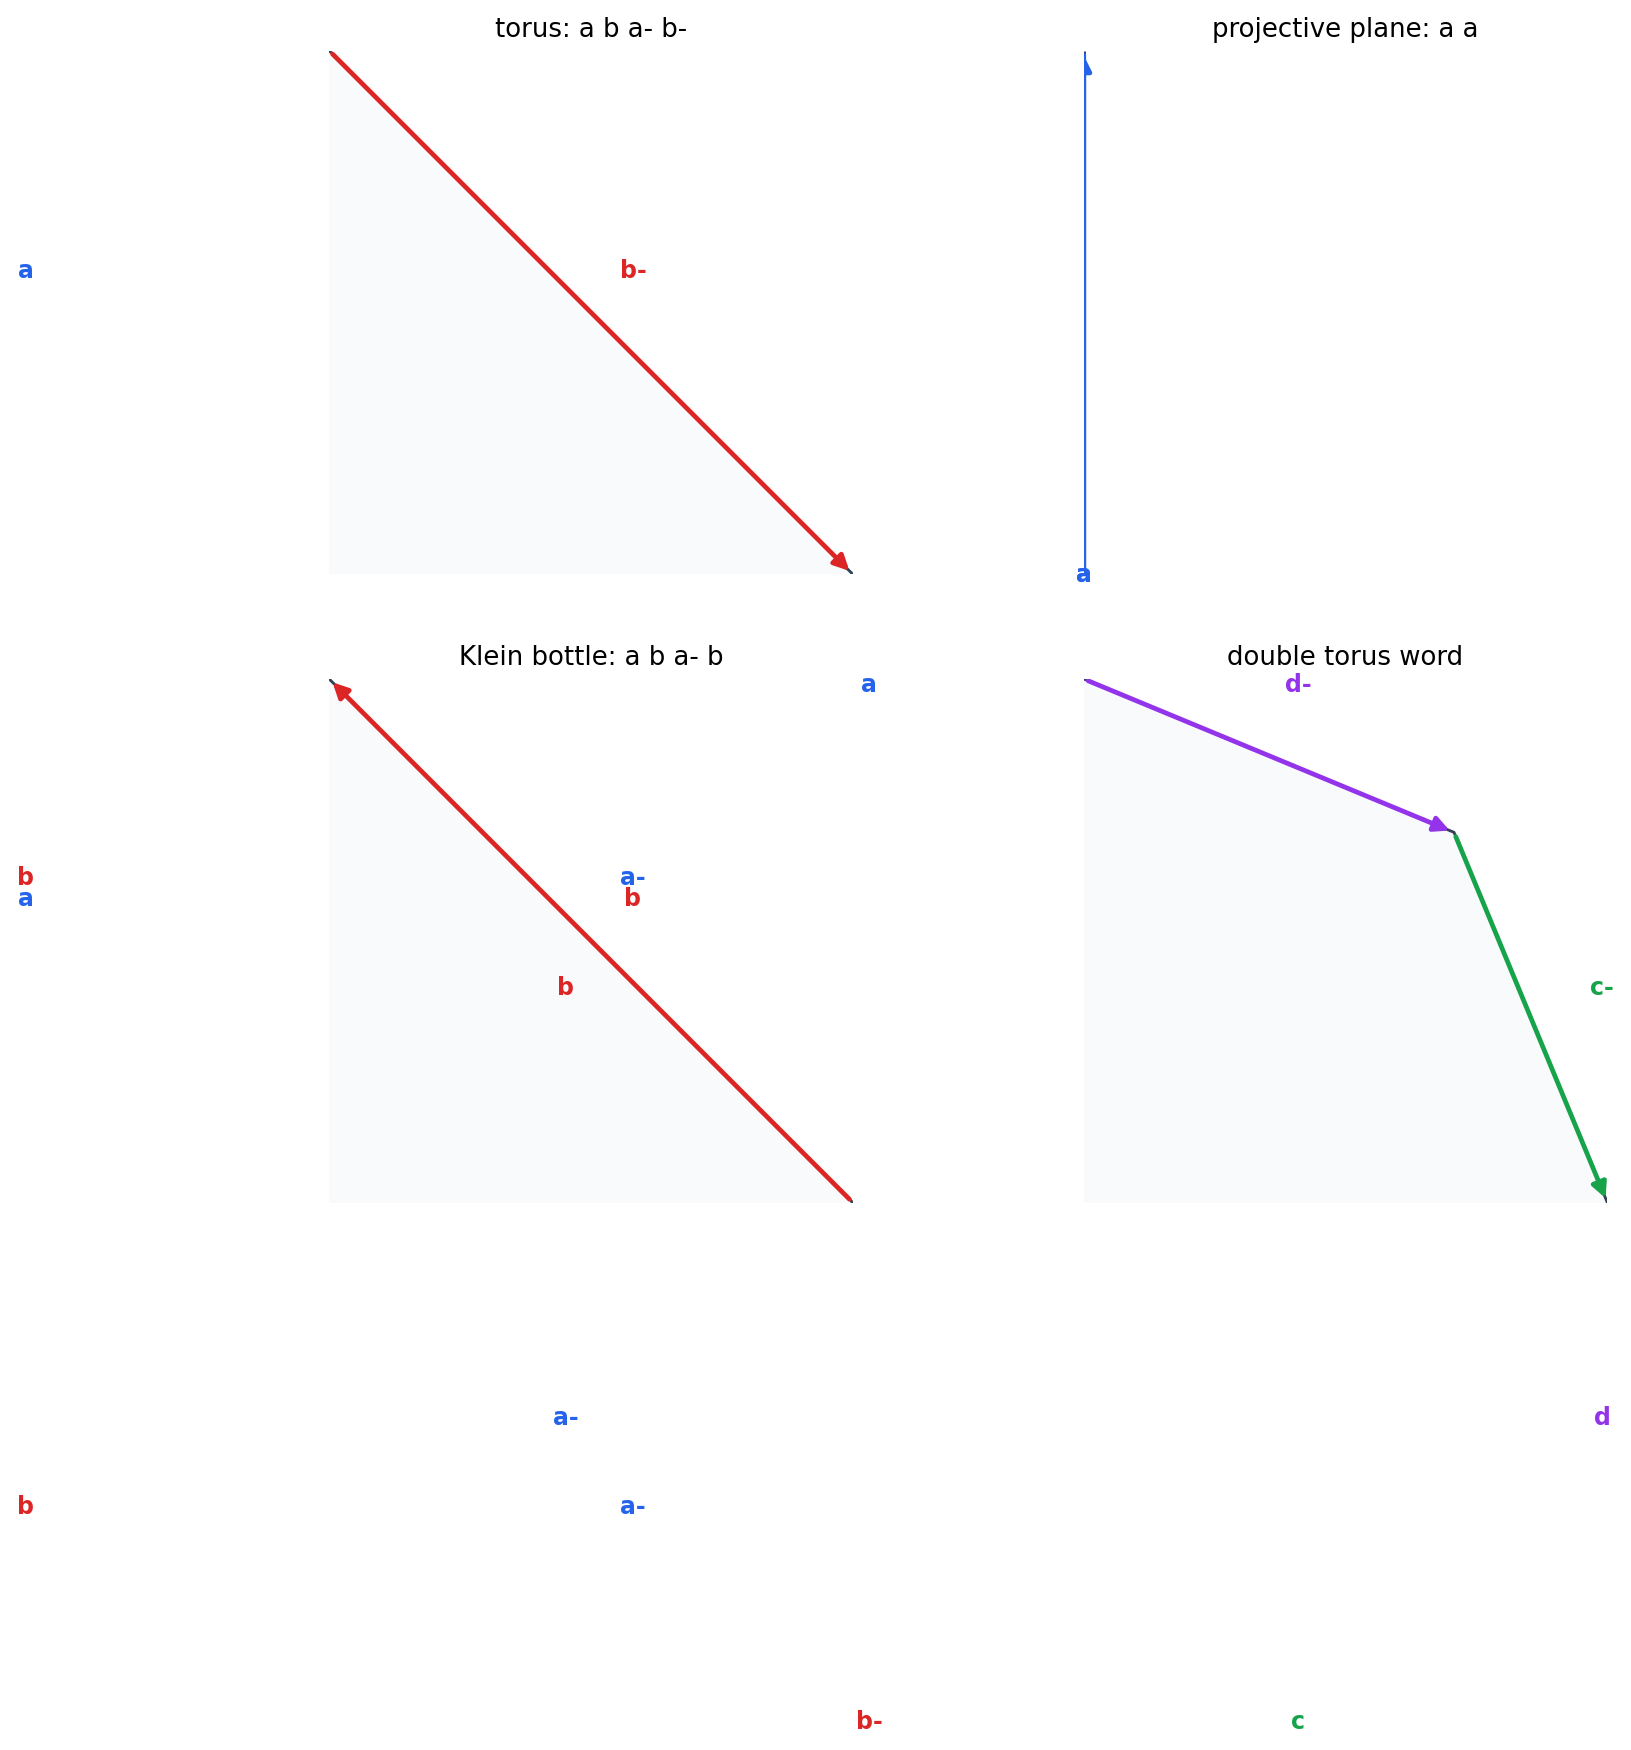

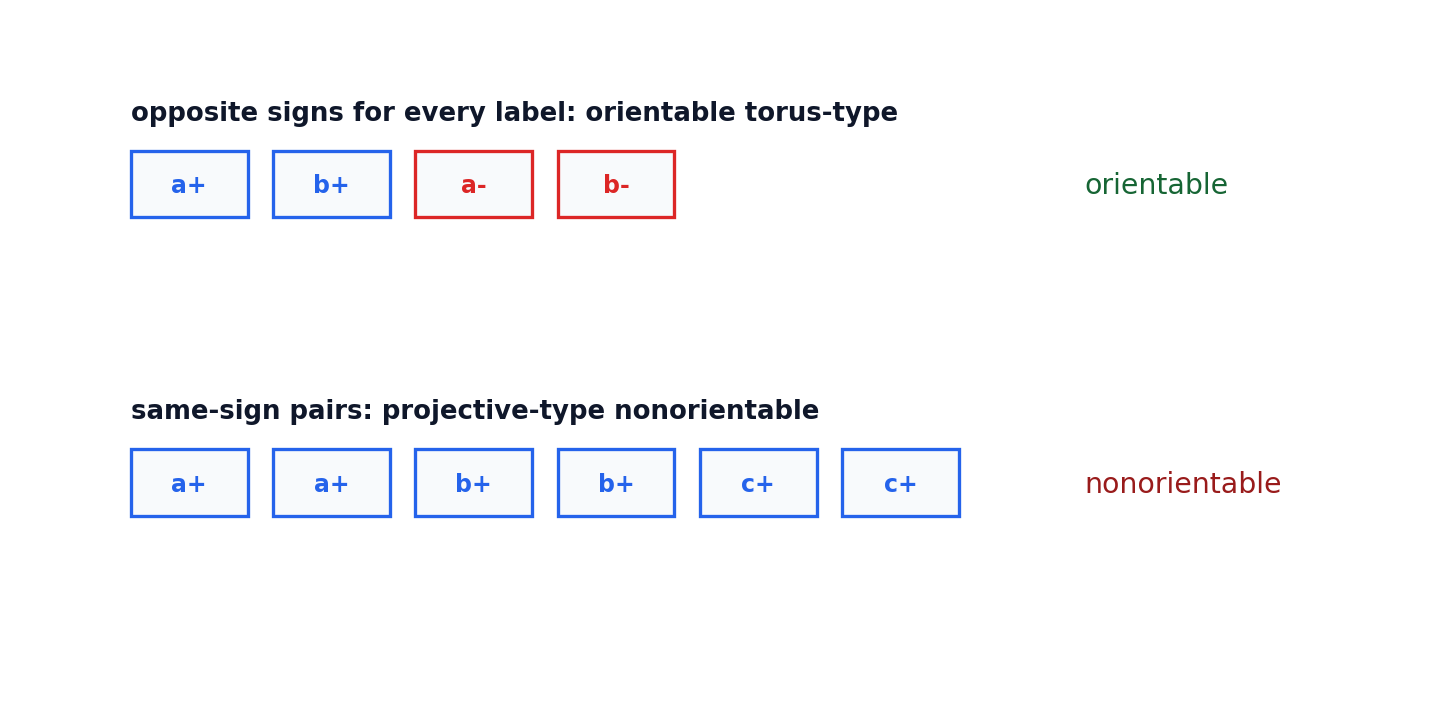

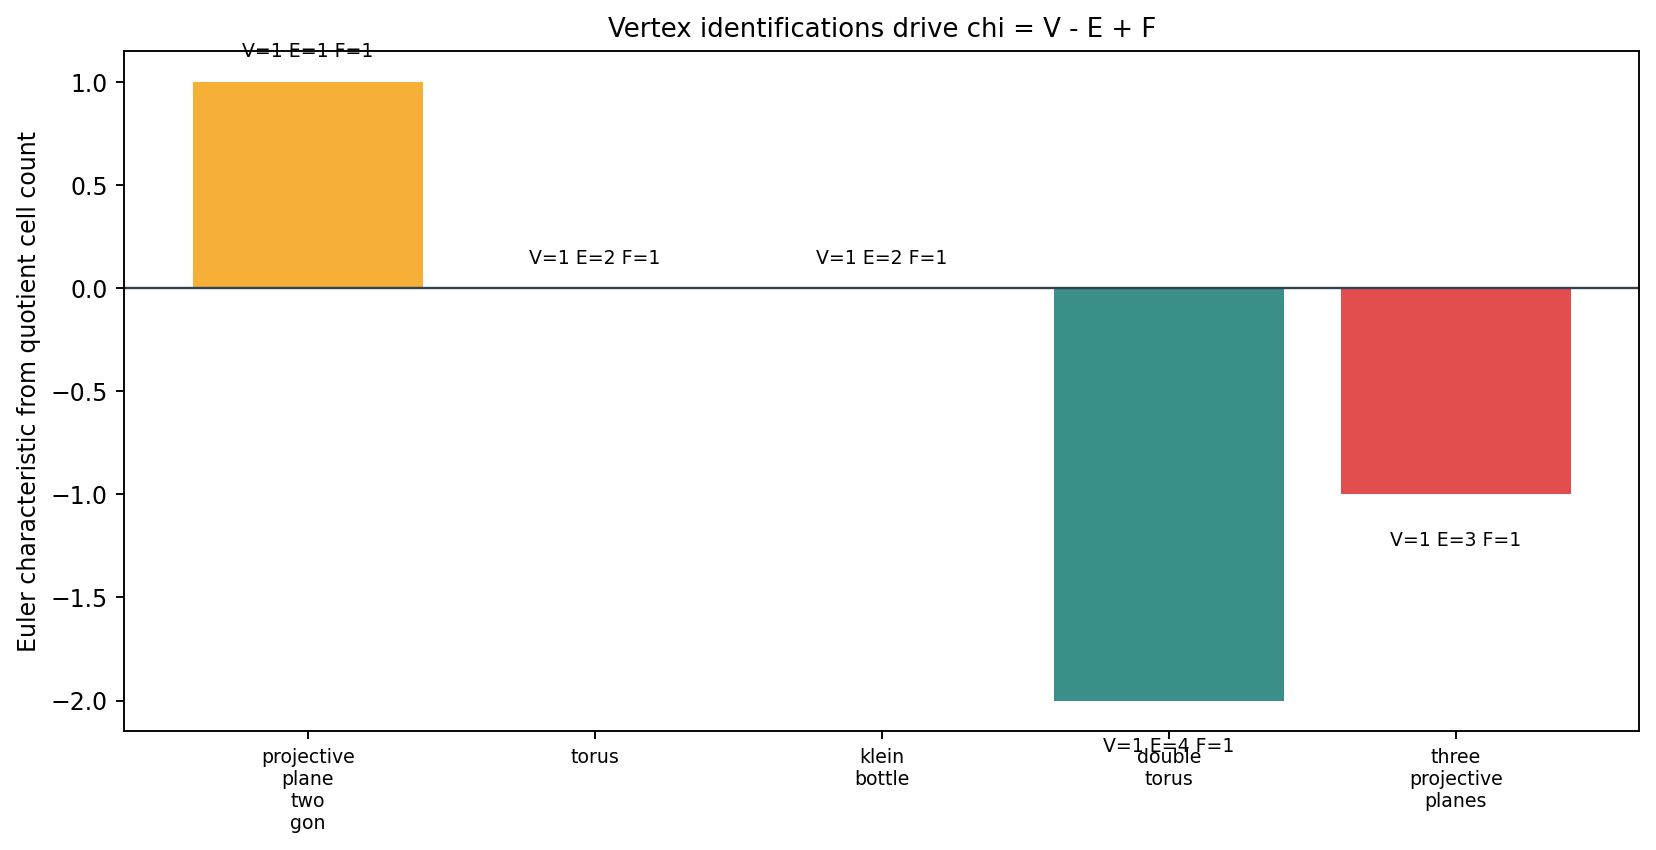

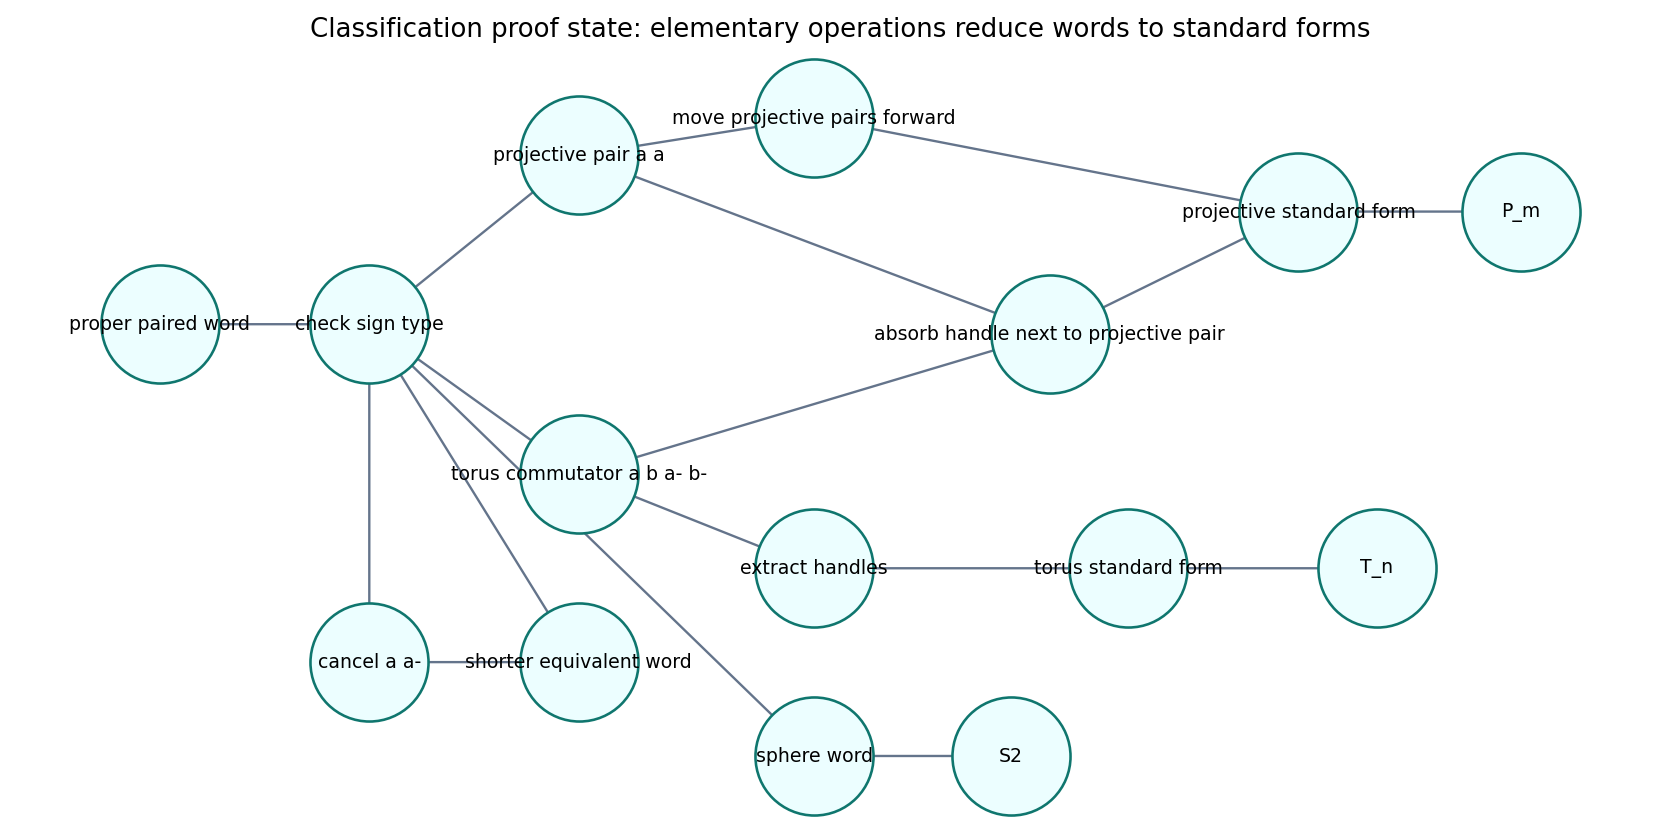

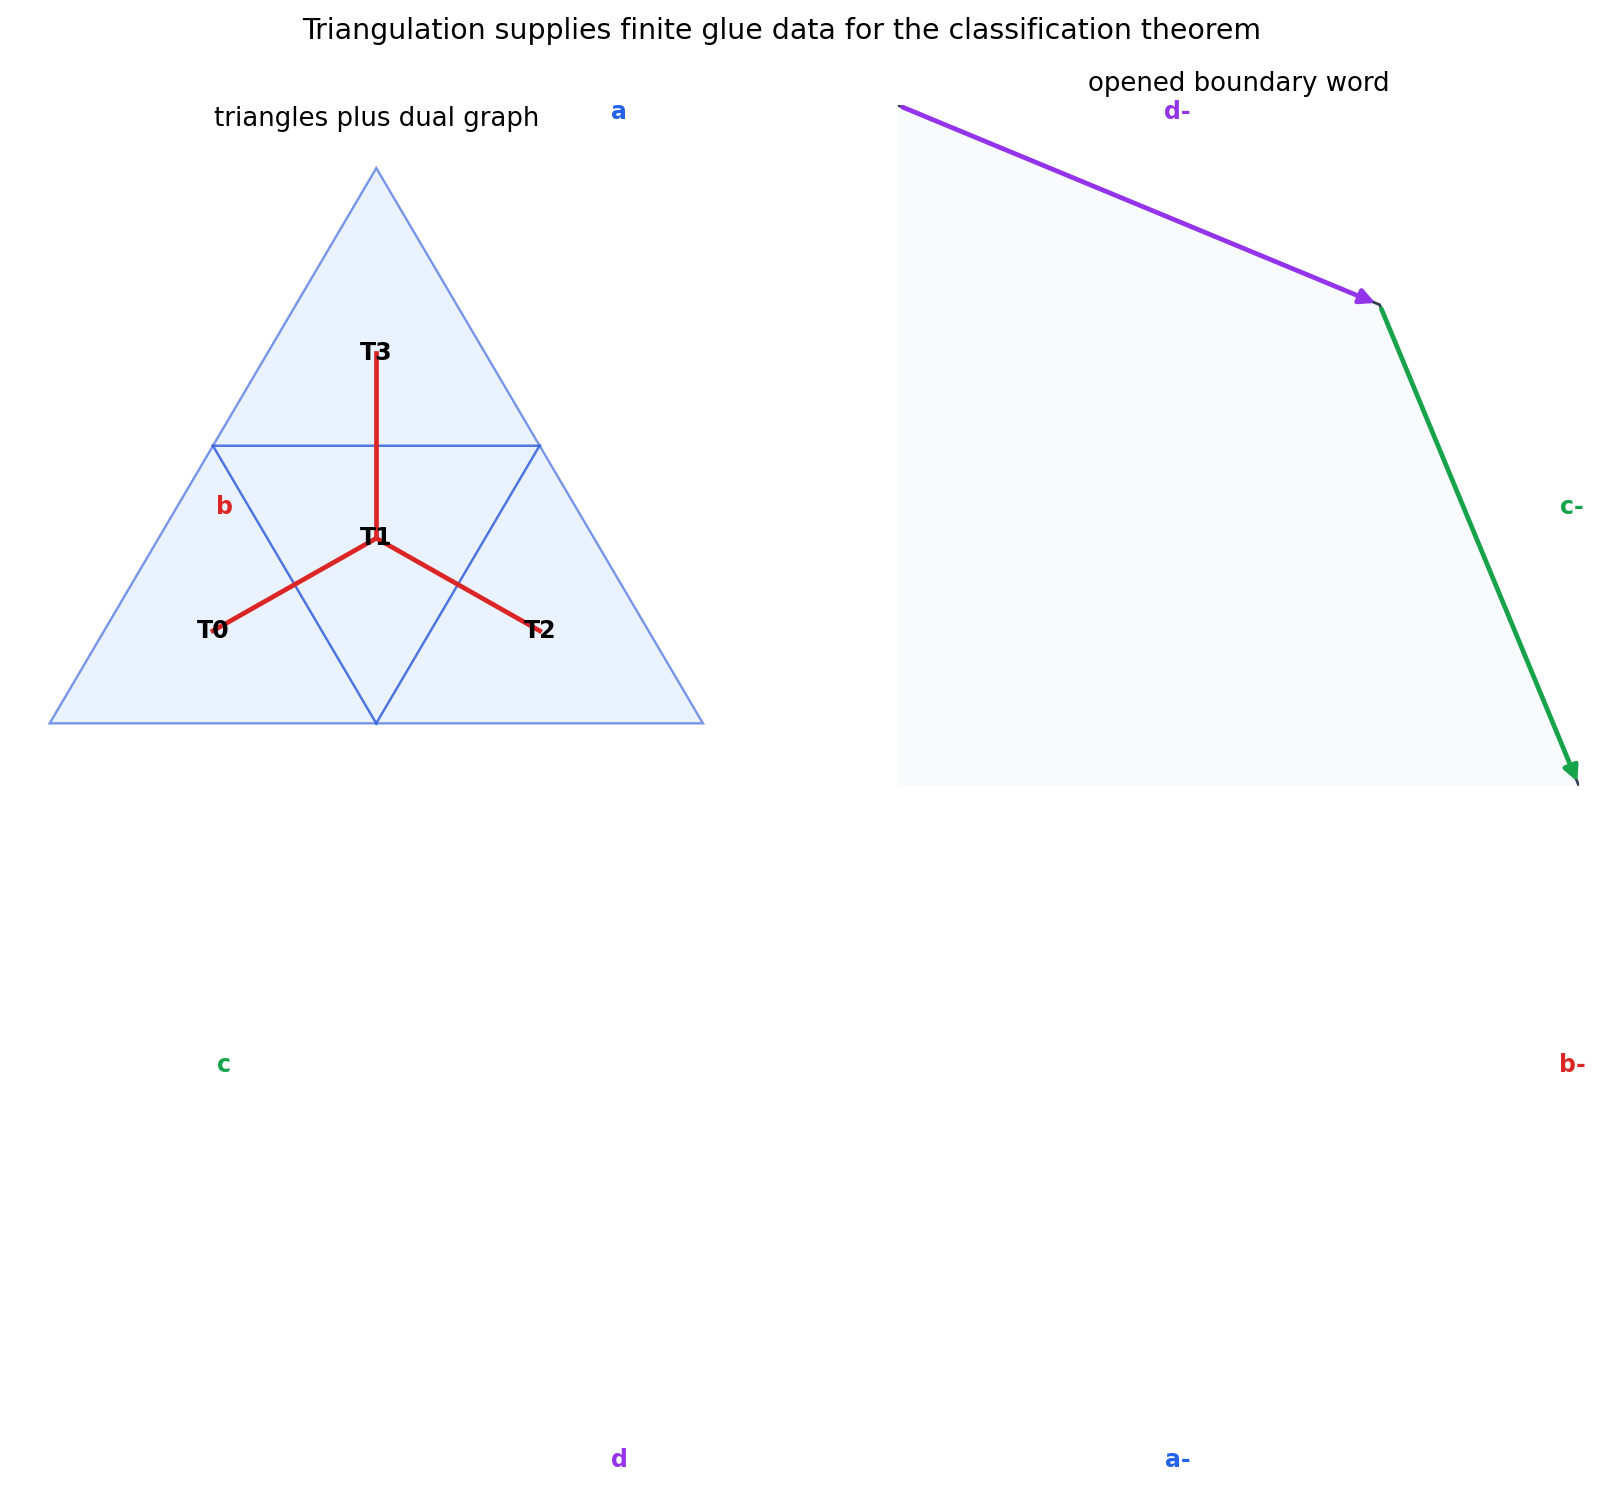

In [8]:
display_order = [
    artifact_paths["polygon_schema"],
    artifact_paths["orientability_strips"],
    artifact_paths["euler_ledger"],
    artifact_paths["reduction_flow"],
    artifact_paths["surface_models"],
    artifact_paths["triangulation_flow"],
    artifact_paths["orientability_table"],
]
assert_artifacts(display_order)
for item in display_order[:4]:
    display_artifact(item, width=760)
display_artifact(display_order[4], width="100%", height=620)
display_artifact(display_order[5], width=760)
display_artifact(display_order[6])


## Applied Lab: Classify A Word By Its First Invariants

The full reduction algorithm uses elementary operations, but the first invariants already separate many cases. The lab classifies several proper words by sign type and Euler characteristic. For orientable one-face words, `chi = 2 - 2g` gives the genus. For nonorientable standard words, `chi = 2 - m` gives the number of projective-plane summands.

Read this lab as a front door to the theorem rather than as the whole theorem. Euler characteristic and orientability are strong invariants, but they do not themselves perform the cutting-and-pasting reductions. The reduction proof supplies the missing constructive step: it shows how the word can be rearranged, cut, pasted, flipped, and cancelled until the invariant hint is represented by one of the standard words. This is why the notebook keeps both views. The tables make the invariant bookkeeping visible, while the proof graph records where the geometric operations enter.

There is also a triangulation caveat. The final section of the source span assumes a triangulable compact surface, then explains how triangles can be opened into polygonal data. The finite code here models that passage by a dual graph and a boundary word; it does not claim to prove every compact surface is triangulable. Within the chapter's stated framework, the computational object to audit is the labelled polygonal quotient, and the checks below make sure its cell counts, signs, and standard-form branches agree with the classification story.


In [9]:
def first_pass_classification(word):
    data = schema_invariants(word)
    if not data["proper"]:
        label = "not a proper paired schema"
    elif data["orientable_by_signs"]:
        genus = int((2 - data["chi"]) / 2) if (2 - data["chi"]) % 2 == 0 else None
        label = "sphere" if genus == 0 else f"orientable genus {genus} candidate"
    else:
        m = int(2 - data["chi"])
        label = f"nonorientable P_{m} candidate"
    return {"word": word, "chi": data["chi"], "orientable": data["orientable_by_signs"], "classification_hint": label}

lab_words = [
    "a b a- b-",
    "a a",
    "a b a- b",
    "a b a- b- c d c- d-",
    "a a b b c c",
]
lab_rows = [first_pass_classification(word) for word in lab_words]
artifact_paths["classification_lab"] = save_table(lab_rows, CHAPTER_ARTIFACT, "tables", "classification-first-pass-lab.csv")
checks["classification_lab_rows"] = len(lab_rows)
checks["classification_lab_has_nonorientable"] = any(not row["orientable"] for row in lab_rows)
lab_rows


[{'word': 'a b a- b-',
  'chi': 0,
  'orientable': True,
  'classification_hint': 'orientable genus 1 candidate'},
 {'word': 'a a',
  'chi': 1,
  'orientable': False,
  'classification_hint': 'nonorientable P_1 candidate'},
 {'word': 'a b a- b',
  'chi': 0,
  'orientable': False,
  'classification_hint': 'nonorientable P_2 candidate'},
 {'word': 'a b a- b- c d c- d-',
  'chi': -2,
  'orientable': True,
  'classification_hint': 'orientable genus 2 candidate'},
 {'word': 'a a b b c c',
  'chi': -1,
  'orientable': False,
  'classification_hint': 'nonorientable P_3 candidate'}]

## Sanity Checks

The final checks verify chapter-specific invariants: schema parsing is proper where expected, orientability matches sign type, Euler characteristics match the standard forms, the proof graph reaches all classification outputs, and every artifact is present and nonblank.


In [10]:
all_artifacts = [
    artifact_paths["polygon_schema"],
    artifact_paths["orientability_strips"],
    artifact_paths["euler_ledger"],
    artifact_paths["reduction_flow"],
    artifact_paths["surface_models"],
    artifact_paths["triangulation_flow"],
    artifact_paths["orientability_table"],
    artifact_paths["classification_lab"],
]
assert_artifacts(all_artifacts)

png_stats = [assert_png_nonblank(path) for path in all_artifacts if path.suffix.lower() == ".png"]
for stat in png_stats:
    assert stat["width"] >= 300 and stat["height"] >= 240

assert checks["torus_chi"] == 0
assert checks["projective_plane_chi"] == 1
assert checks["double_torus_chi"] == -2
assert checks["torus_orientable"] is True
assert checks["projective_plane_nonorientable"] is True
assert checks["classification_graph_reaches_all_standard_forms"] is True
assert checks["surface_model_trace_count"] == 3
assert checks["triangulation_boundary_word_proper"] is True
assert checks["classification_lab_has_nonorientable"] is True

storyboard = {
    "chapter": 12,
    "title": "Classification of Surfaces",
    "source_span": "printed pages 468-498; sections 74-78",
    "artifacts": [rel(path) for path in all_artifacts],
    "checks": checks,
    "library_routing": {
        "matplotlib": "polygon schemas, orientability strips, Euler ledger, and triangulation scaffold",
        "networkx": "classification proof dependency graph",
        "plotly": "rotatable standard-surface memory aids",
        "numpy": "surface sampling and quotient diagnostics",
    },
}
artifact_paths["storyboard"] = save_json(storyboard, CHAPTER_ARTIFACT, "checks", "visual-storyboard.json")
artifact_paths["summary"] = save_json({"chapter": 12, "checks": checks, "ledger": ledger}, CHAPTER_ARTIFACT, "checks", "chapter-summary.json")
artifact_paths["final_sanity"] = save_json({
    "chapter": 12,
    "notebook_executed": True,
    "artifact_count": len(all_artifacts),
    "png_count": len(png_stats),
    "artifacts": [rel(path) for path in all_artifacts],
    "check_keys": sorted(checks),
}, CHAPTER_ARTIFACT, "checks", "final-sanity.json")
assert_artifacts([artifact_paths["storyboard"], artifact_paths["summary"], artifact_paths["final_sanity"]])
{"artifact_count": len(all_artifacts), "png_count": len(png_stats), "checks": checks}


{'artifact_count': 8,
 'png_count': 5,
 'checks': {'torus_chi': 0,
  'projective_plane_chi': 1,
  'double_torus_chi': -2,
  'torus_orientable': True,
  'projective_plane_nonorientable': True,
  'orientability_rows': 6,
  'schema_chi_values': {'projective_plane_two_gon': 1,
   'torus': 0,
   'klein_bottle': 0,
   'double_torus': -2,
   'three_projective_planes': -1},
  'classification_graph_reaches_all_standard_forms': True,
  'surface_model_trace_count': 3,
  'triangulation_dual_tree_edges': 3,
  'triangulation_boundary_word_proper': True,
  'classification_lab_rows': 5,
  'classification_lab_has_nonorientable': True}}

## Takeaways

- A compact surface can be studied through finite quotient data once it is represented by a polygon schema.
- Orientability is visible in the signs of paired edge labels; same-sign pairs signal projective-plane behavior.
- Euler characteristic must be computed after vertex identifications, not from the unglued polygon picture.
- Elementary cutting and pasting operations form a reduction algorithm from arbitrary proper words to standard sphere, torus-sum, or projective-sum forms.
- The triangulation step explains why this finite word model applies to triangulable compact surfaces rather than only to hand-drawn polygons.
